### **FITBIT : CALORIES BURN PREDICTION**

In [65]:
import pandas as pd
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import StandardScaler
import numpy as np

In [66]:
df=pd.read_csv('/content/Fitbit_dataset.csv')
df.head()

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


In [67]:
df.columns

Index(['Unnamed: 0', 'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM',
       'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type',
       'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET',
       'HR_Intensity', 'Effective_MET', 'Calories_Burned (kcal)'],
      dtype='object')

In [68]:
df.info()#to check types of columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14102 entries, 0 to 14101
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     14102 non-null  int64  
 1   Age                            14102 non-null  int64  
 2   Gender                         14102 non-null  object 
 3   Weight (kg)                    14102 non-null  float64
 4   Height (m)                     14102 non-null  float64
 5   Max_BPM                        14102 non-null  float64
 6   Avg_BPM                        14102 non-null  float64
 7   Resting_BPM                    14102 non-null  float64
 8   Session_Duration (hours)       14102 non-null  float64
 9   Workout_Type                   14102 non-null  object 
 10  Fat_Percentage                 14102 non-null  float64
 11  Water_Intake (liters)          14102 non-null  float64
 12  Workout_Frequency (days/week)  14102 non-null 

In [69]:
#To handel inconsistent category

for i in df.select_dtypes(include="object").columns:
    print(i,"\t",df[i].unique())
    print("********************")

Gender 	 ['Female' 'Male']
********************
Workout_Type 	 ['HIIT' 'Yoga' 'Cardio' 'Mixed' 'Strength']
********************


In [70]:
#To check if their is any null value or not
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Gender,0
Weight (kg),0
Height (m),0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Workout_Type,0


In [71]:
#To check if their is any dupicate values
df.duplicated().sum()

np.int64(0)

In [72]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [73]:
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


In [74]:
encode = LabelEncoder()#As machine learning needs only number so encoding Fender and workout type into int type by encoding them
df["Gender"] = encode.fit_transform(df["Gender"])
df["Workout_Type"] = encode.fit_transform(df["Workout_Type"])

In [75]:
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,56,0,53.8,1.62,163.0,149.0,71.0,1.01,1,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,46,1,54.9,1.75,170.0,126.0,73.0,0.25,4,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,32,0,68.5,1.61,190.0,171.0,60.0,0.33,1,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,25,1,98.8,1.86,189.0,135.0,69.0,0.78,4,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,38,1,95.5,1.71,176.0,138.0,66.0,0.55,0,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


In [76]:


print(encode.classes_)

['Cardio' 'HIIT' 'Mixed' 'Strength' 'Yoga']


In [77]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type',
       'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET',
       'HR_Intensity', 'Effective_MET', 'Calories_Burned (kcal)'],
      dtype='object')

In [78]:
B=['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type',
       'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET',
       'HR_Intensity', 'Effective_MET']

                                    Age    Gender  Weight (kg)  Height (m)  \
Age                            1.000000  0.002409    -0.007873   -0.002200   
Gender                         0.002409  1.000000     0.013955    0.001550   
Weight (kg)                   -0.007873  0.013955     1.000000    0.590935   
Height (m)                    -0.002200  0.001550     0.590935    1.000000   
Max_BPM                       -0.924647 -0.002125     0.004869   -0.003261   
Avg_BPM                       -0.566087  0.001189     0.002187   -0.008306   
Resting_BPM                    0.002534 -0.004471     0.016174    0.006583   
Session_Duration (hours)       0.002773 -0.008386    -0.009361   -0.000509   
Workout_Type                  -0.005571 -0.007829     0.009347    0.005402   
Fat_Percentage                 0.004372 -0.244843     0.005044   -0.000840   
Water_Intake (liters)         -0.003199 -0.002831     0.001677    0.007468   
Workout_Frequency (days/week)  0.005660 -0.001648    -0.006806  

<Axes: >

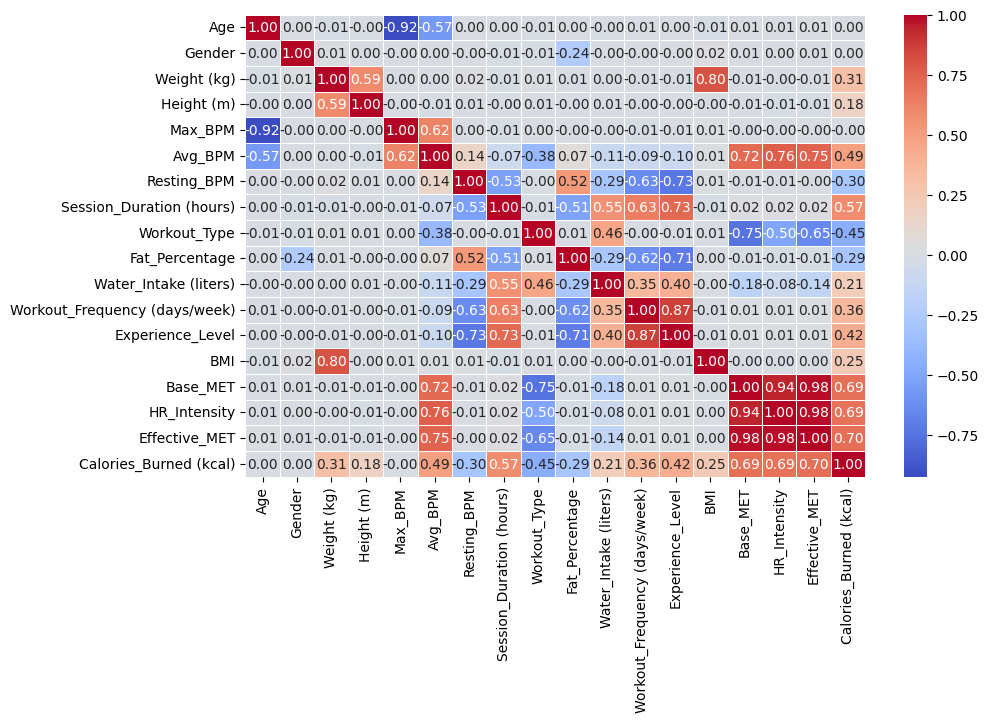

In [79]:
import pandas as pd

# assuming your dataframe is df
corr_matrix =df.corr(numeric_only=True)

print(corr_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,        # show values
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm",   # color theme
    linewidths=0.5
)


                                    Age   Avg_BPM  Resting_BPM  \
Age                            1.000000 -0.566087     0.002534   
Avg_BPM                       -0.566087  1.000000     0.143383   
Resting_BPM                    0.002534  0.143383     1.000000   
Session_Duration (hours)       0.002773 -0.068967    -0.527744   
Workout_Type                  -0.005571 -0.379687    -0.000180   
Fat_Percentage                 0.004372  0.066569     0.516702   
Workout_Frequency (days/week)  0.005660 -0.091298    -0.634277   
BMI                           -0.008453  0.009158     0.013474   
Base_MET                       0.007341  0.718684    -0.005033   
HR_Intensity                   0.007345  0.764717    -0.005279   

                               Session_Duration (hours)  Workout_Type  \
Age                                            0.002773     -0.005571   
Avg_BPM                                       -0.068967     -0.379687   
Resting_BPM                                   -0.52774

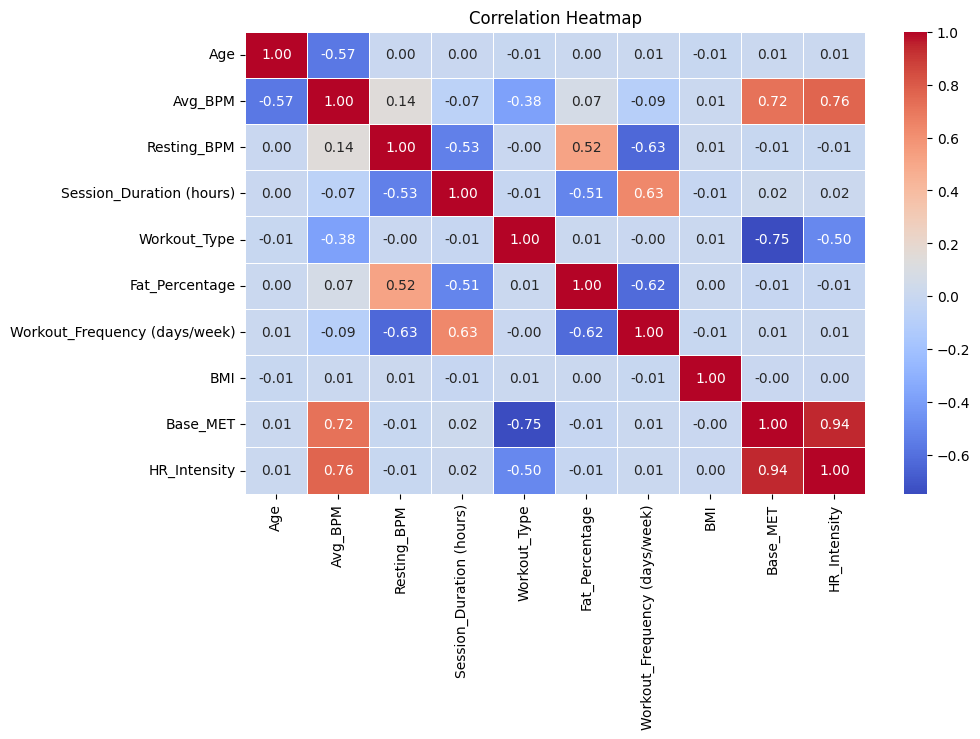

In [174]:
import pandas as pd

# assuming your dataframe is df
corr_matrix = x.corr(numeric_only=True)

print(corr_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,        # show values
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm",   # color theme
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Keeping both Workout_Frequency and Experience_Level introduces multicollinearity because they are highly correlated. This leads to redundancy, unstable model

In [81]:
#so from above we can say that Gender,Bmi,water_intake,Effective MET,experience level

In [82]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type',
       'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET',
       'HR_Intensity', 'Effective_MET', 'Calories_Burned (kcal)'],
      dtype='object')

In [83]:
# df.drop(columns=['Gender', 'BMI','Water_Intake (liters)','Effective_MET','Experience_Level','Max_BPM'], inplace=True)

In [84]:
df.drop(columns=['Gender', 'Weight (kg)','Height (m)','Water_Intake (liters)','Effective_MET','Experience_Level','Max_BPM'], inplace=True)

In [85]:
df

,Age,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Workout_Frequency (days/week),BMI,Base_MET,HR_Intensity,Calories_Burned (kcal)
0,56,149.0,71.0,1.01,1,22.1,3,20.4,9.5,0.847826,437.7
1,46,126.0,73.0,0.25,4,19.9,3,18.0,3.0,0.546392,22.5
2,32,171.0,60.0,0.33,1,20.4,3,26.5,9.5,0.853846,183.4
3,25,135.0,69.0,0.78,4,30.3,3,28.5,3.0,0.550000,127.2
4,38,138.0,66.0,0.55,0,23.7,2,32.5,7.0,0.654545,240.7
...,...,...,...,...,...,...,...,...,...,...,...
14097,18,143.0,67.0,0.62,4,23.3,4,24.3,3.0,0.550725,77.5
14098,54,131.0,73.0,0.93,0,15.0,3,22.7,7.0,0.651685,281.7
14099,23,161.0,61.0,0.99,3,19.3,3,32.5,6.0,0.699301,310.3
14100,43,154.0,55.0,1.01,1,12.3,7,24.9,9.5,0.853448,579.8


In [86]:
df.kurtosis()

,0
Age,-1.171135
Avg_BPM,-0.417566
Resting_BPM,-0.630501
Session_Duration (hours),-0.443572
Workout_Type,-1.290510
Fat_Percentage,-0.389949
Workout_Frequency (days/week),-1.045708
BMI,-0.469525
Base_MET,-0.759539
HR_Intensity,-0.951313


In [87]:
df.skew()

,0
Age,0.003135
Avg_BPM,0.185845
Resting_BPM,-0.069268
Session_Duration (hours),0.191875
Workout_Type,0.007940
Fat_Percentage,-0.094860
Workout_Frequency (days/week),0.392939
BMI,0.275033
Base_MET,-0.525490
HR_Intensity,-0.016123


In [88]:
for i in df.columns:
    if df[i].skew()<0.5 and df[i].skew()>-0.5 and df[i].kurtosis()<3 and df[i].kurtosis()>-3:
        continue
    print("****************************")
    print(i)
    method  = [-2,-1,-0.5,0,0.5,1,2]
    for j in method:
        print(j)
        print("skewness",pd.DataFrame(stats.boxcox(df[i],lmbda=j)).skew().values[0],"kurtosis",pd.DataFrame(stats.boxcox(df[i],lmbda=j)).kurtosis().values[0])

****************************
Base_MET
-2
skewness -1.4453510401994754 kurtosis 0.21891504936287864
-1
skewness -1.2994078565614957 kurtosis 0.02152861515633253
-0.5
skewness -1.1702358348004587 kurtosis -0.14122583409917677
0
skewness -0.9950199346637008 kurtosis -0.34240214779804656
0.5
skewness -0.7760672806026938 kurtosis -0.5599939586953924
1
skewness -0.5254902262300064 kurtosis -0.7595394218003828
2
skewness -0.007567891625454626 kurtosis -0.9840107071147406
****************************
Calories_Burned (kcal)
-2
skewness -7.627218055147334 kurtosis 84.99585918897836
-1
skewness -2.8407574945354184 kurtosis 12.038426703927813
-0.5
skewness -1.4722008198568315 kurtosis 2.745829019082993
0
skewness -0.5244674847998683 kurtosis -0.12051423594469446
0.5
skewness 0.2604494085153122 kurtosis -0.3159526847883858
1
skewness 1.0422615630881193 kurtosis 1.3831264935131045
2
skewness 3.0344569203360514 kurtosis 15.730165743032316


In [89]:
df["Calories_Burned (kcal)"] = stats.boxcox(df["Calories_Burned (kcal)"],lmbda=0.5)

In [90]:
df.skew()

,0
Age,0.003135
Avg_BPM,0.185845
Resting_BPM,-0.069268
Session_Duration (hours),0.191875
Workout_Type,0.007940
Fat_Percentage,-0.094860
Workout_Frequency (days/week),0.392939
BMI,0.275033
Base_MET,-0.525490
HR_Intensity,-0.016123


In [91]:
df

,Age,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Workout_Frequency (days/week),BMI,Base_MET,HR_Intensity,Calories_Burned (kcal)
0,56,149.0,71.0,1.01,1,22.1,3,20.4,9.5,0.847826,39.842562
1,46,126.0,73.0,0.25,4,19.9,3,18.0,3.0,0.546392,7.486833
2,32,171.0,60.0,0.33,1,20.4,3,26.5,9.5,0.853846,25.085051
3,25,135.0,69.0,0.78,4,30.3,3,28.5,3.0,0.550000,20.556595
4,38,138.0,66.0,0.55,0,23.7,2,32.5,7.0,0.654545,29.029019
...,...,...,...,...,...,...,...,...,...,...,...
14097,18,143.0,67.0,0.62,4,23.3,4,24.3,3.0,0.550725,15.606817
14098,54,131.0,73.0,0.93,0,15.0,3,22.7,7.0,0.651685,31.567842
14099,23,161.0,61.0,0.99,3,19.3,3,32.5,6.0,0.699301,33.230668
14100,43,154.0,55.0,1.01,1,12.3,7,24.9,9.5,0.853448,46.158073


In [92]:
x=df.iloc[:,:-1]


In [93]:
x

,Age,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Workout_Frequency (days/week),BMI,Base_MET,HR_Intensity
0,56,149.0,71.0,1.01,1,22.1,3,20.4,9.5,0.847826
1,46,126.0,73.0,0.25,4,19.9,3,18.0,3.0,0.546392
2,32,171.0,60.0,0.33,1,20.4,3,26.5,9.5,0.853846
3,25,135.0,69.0,0.78,4,30.3,3,28.5,3.0,0.550000
4,38,138.0,66.0,0.55,0,23.7,2,32.5,7.0,0.654545
...,...,...,...,...,...,...,...,...,...,...
14097,18,143.0,67.0,0.62,4,23.3,4,24.3,3.0,0.550725
14098,54,131.0,73.0,0.93,0,15.0,3,22.7,7.0,0.651685
14099,23,161.0,61.0,0.99,3,19.3,3,32.5,6.0,0.699301
14100,43,154.0,55.0,1.01,1,12.3,7,24.9,9.5,0.853448


In [94]:
x.head(2)

,Age,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Workout_Frequency (days/week),BMI,Base_MET,HR_Intensity
0,56,149.0,71.0,1.01,1,22.1,3,20.4,9.5,0.847826
1,46,126.0,73.0,0.25,4,19.9,3,18.0,3.0,0.546392


In [95]:
y=df.iloc[:,-1]

In [96]:
y.head(2)

,Calories_Burned (kcal)
0,39.842562
1,7.486833


In [97]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [98]:
 x_train.shape , x_test.shape , y_train.shape , y_test.shape

((11281, 10), (2821, 10), (11281,), (2821,))

In [135]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)   #we are only sacling the X part '''
x_test=scaler.transform(x_test)#we will use fit_transform with training data and transform with test data

In [100]:
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score

In [101]:
x.shape

(14102, 10)

In [ ]:
x

LASSO

In [102]:
from sklearn.linear_model import Lasso

# Model
lasso = Lasso(alpha=0.1)
lasso.fit(x_train, y_train)

# Prediction
y_pred = lasso.predict(x_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))
import pickle
# Saveing both model and scaler
pickle.dump(lasso, open("lasso.pkl", "wb"))
pickle.dump(scaler, open("lasso_scaler.pkl", "wb"))

MAE: 2.029968650341214
MSE: 6.8071992848816265
RMSE: 2.6090609967729055
R2 Score: 0.9369877375402604


In [103]:
y_pred

array([35.85913296, 38.84163005, 17.01299618, ..., 42.94197398,
       30.51344449, 37.5317678 ])

In [104]:
y_test

,Calories_Burned (kcal)
811,35.571266
8732,42.904343
708,17.308029
1213,20.600885
1086,31.214455
...,...
1479,24.442390
11975,36.822674
11583,44.656189
6335,25.121947


In [138]:
import pickle
# Saveing both model and scaler
pickle.dump(lasso, open("lasso2.pkl", "wb"))
pickle.dump(scaler, open("lasso2_scaler.pkl", "wb"))

In [127]:
lasso.predict([x_test[0]])
print(x_test)

[[-0.95861011  1.08690978 -1.1755671  ...  1.3389123   0.58189562
   0.49655443]
 [-0.70727573  0.9501581  -0.18840226 ...  0.78189685  0.58189562
   0.49830013]
 [-0.53971947 -0.62248623  0.51671548 ...  0.56970049 -1.70853162
  -1.55993033]
 ...
 [ 1.21962119  0.26639969 -0.61147291 ... -1.4196404   1.26902379
   1.5041814 ]
 [ 1.21962119  0.60827889  2.20899807 ... -0.83610041  1.26902379
   1.54605125]
 [ 0.80073056 -0.62248623 -0.04737871 ...  1.23281412 -0.33427528
  -0.01988113]]


In [133]:
[x_test[0]]

[array([-0.95861011,  1.08690978, -1.1755671 , -0.24018514, -0.00214905,
        -1.55480914,  1.12729061,  1.3389123 ,  0.58189562,  0.49655443])]

In [130]:
[[48,106,60,1.01,0,22.23,3,20.37,9.50,2]]

[[48, 106, 60, 1.01, 0, 22.23, 3, 20.37, 9.5, 2]]

In [134]:
lasso.predict([[48,106,60,1.01,0,22.23,3,20.37,9.50,2]])

array([140.63102933])

In [139]:
val=scaler.transform([[48,106,60,1.01,0,22.23,3,20.37,9.50,2]])

In [ ]:
[[48,106,60,1.01,0,22.23,3,20.37,9.50,2]]

In [140]:
lasso.predict(val)

array([140.63102933])

In [141]:
val2=[[20,120,70,1,0,20,3,22,5,1]]

In [142]:
lasso.predict(val2)

array([117.5967024])

RIDGE

In [106]:
from sklearn.linear_model import Ridge

# Model
ridge = Ridge(alpha=0.1)
ridge.fit(x_train, y_train)

# Prediction
y_pred = ridge.predict(x_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test,y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2.0230365548788445
MSE: 6.714905224701159
RMSE: 2.59131341691837
R2 Score: 0.9378420767920116


In [107]:
pickle.dump(model_AdaBoostRegressor,open("model_AdaBoostRegressor.pkl", "wb"))
pickle.dump(scaler, open("model_AdaBoostRegressorscaler.pkl", "wb"))

DECISION TREE REGRESSOR

In [108]:
from sklearn.tree import DecisionTreeRegressor
# Model
model_DecisionTreeRegressor =DecisionTreeRegressor().fit(x_train,y_train)
# Prediction
y_pred =model_DecisionTreeRegressor.predict(x_test)
# Evaluation
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2_score",r2_score(y_test,y_pred))

MAE 2.273207899264391
MSE 8.796102300799584
RMSE: 2.965822365011024
R2_score 0.9185770412169826


ADA BOOST REGRESSOR

In [109]:
from sklearn.ensemble import AdaBoostRegressor
# Model
model_AdaBoostRegressor= AdaBoostRegressor().fit(x_train , y_train)
# Prediction
y_pred = model_AdaBoostRegressor.predict(x_test)
# Evaluation
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2_score",r2_score(y_test,y_pred))

MAE 2.4340323148461587
MSE 9.141805154669642
RMSE: 3.0235418228742335
R2_score 0.9153769705198427


RANDOM FOREST REGRESSOR

In [111]:
from sklearn.ensemble import RandomForestRegressor
# Model
model_RandomForestRegressor = RandomForestRegressor().fit(x_train , y_train)
# Prediction
y_pred = model_RandomForestRegressor.predict(x_test)
# Evaluation
print("mae",mean_absolute_error(y_test,y_pred))
print("mse",mean_squared_error(y_test,y_pred))
print("r2_score",r2_score(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

mae 1.648495091660284
mse 4.488083407428545
r2_score 0.9584551182101895
RMSE: 2.118509713791406


LINEAR REGRESSION

In [112]:
from sklearn.linear_model import LinearRegression
# Model
model_LinearRegression = LinearRegression().fit(x_train , y_train)
# Prediction
y_pred = model_LinearRegression.predict(x_test)
# Evaluation
print("mae",mean_absolute_error(y_test,y_pred))
print("mse",mean_squared_error(y_test,y_pred))
print("r2_score",r2_score(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

mae 2.023028669244246
mse 6.7148231120584665
r2_score 0.937842836884845
RMSE: 2.5912975730429855


SVR

In [113]:
from sklearn.svm import SVR
# Model
model_SVR = SVR().fit(x_train , y_train)
# Prediction
y_pred = model_SVR.predict(x_test)
# Evaluation
print("mae",mean_absolute_error(y_test,y_pred))
print("mse",mean_squared_error(y_test,y_pred))
print("r2_score",r2_score(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

mae 1.6232767483119515
mse 4.535629031199741
r2_score 0.9580150022096874
RMSE: 2.129701629618511


XGB REGRESSOR

In [114]:
from xgboost import XGBRegressor
# Model
model_XGBRegressor = XGBRegressor().fit(x_train,y_train)
# Prediction
y_pred = model_XGBRegressor.predict(x_test)
# Evaluation
print("mae",mean_absolute_error(y_test,y_pred))
print("mse",mean_squared_error(y_test,y_pred))
print("r2_score",r2_score(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

mae 1.649342018158262
mse 4.599984824996346
r2_score 0.9574192793580701
RMSE: 2.144757521258836


GRADIENT BOOSTING REGRESSOR

In [116]:
from sklearn.ensemble import GradientBoostingRegressor
# Model
model_GradientBoostingRegressor= GradientBoostingRegressor().fit(x_train , y_train)
# Prediction
y_pred = model_GradientBoostingRegressor.predict(x_test)
# Evaluation
print("mae",mean_absolute_error(y_test,y_pred))
print("mse",mean_squared_error(y_test,y_pred))
print("r2_score",r2_score(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

mae 1.5434769063620124
mse 3.9789265713163435
r2_score 0.963168234845621
RMSE: 1.9947246855935643


K NEIGHBORS REGRESSOR

In [118]:
from sklearn.neighbors import KNeighborsRegressor
#model
model_KNeighborsRegressor= KNeighborsRegressor(n_neighbors=5).fit(x_train, y_train)
y_pred = model_KNeighborsRegressor.predict(x_test)
print("mae", mean_absolute_error(y_test, y_pred))
print("mse", mean_squared_error(y_test, y_pred))
print("r2_score", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

mae 2.0551576009610817
mse 6.935265535886614
r2_score 0.9358022655299898
RMSE: 2.6334892321569523


**CROSS VALIDATION**

In [119]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [143]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
scores = cross_val_score(model, x_train, y_train, cv=kf, scoring='r2')

print("Linear Regression CV R2:", scores)
print("Mean R2:", np.mean(scores))

Linear Regression CV R2: [0.93427689 0.93824093 0.93600945 0.93868792 0.93653428]
Mean R2: 0.9367498931012518


In [144]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=0.1)
scores = cross_val_score(model, x_train, y_train, cv=kf, scoring='r2')

print("Ridge CV R2:", scores)
print("Mean R2:", np.mean(scores))

Ridge CV R2: [0.93427714 0.93824143 0.93600925 0.93868731 0.93653432]
Mean R2: 0.9367498897029171


In [145]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1)
scores = cross_val_score(model, x_train, y_train, cv=kf, scoring='r2')

print("Lasso CV R2:", scores)
print("Mean R2:", np.mean(scores))

Lasso CV R2: [0.93420416 0.93804711 0.93594282 0.93792087 0.9359573 ]
Mean R2: 0.9364144516462127


In [146]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
scores = cross_val_score(model, x_train, y_train, cv=kf, scoring='r2')

print("Decision Tree CV R2:", scores)
print("Mean R2:", np.mean(scores))


Decision Tree CV R2: [0.91404807 0.91973179 0.91744692 0.92160427 0.9166114 ]
Mean R2: 0.9178884878733994


In [147]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
scores = cross_val_score(model, x_train, y_train, cv=kf, scoring='r2')

print("Random Forest CV R2:", scores)
print("Mean R2:", np.mean(scores))

Random Forest CV R2: [0.95512813 0.95751091 0.95799747 0.95899697 0.95800994]
Mean R2: 0.9575286850184697


In [ ]:
from sklearn.ensemble import AdaBoostRegressor

model_AdaBoostRegressor = AdaBoostRegressor()
scores = cross_val_score(model_AdaBoostRegressor, x_train, y_train, cv=kf, scoring='r2')

print("AdaBoost CV R2:", scores)
print("Mean R2:", np.mean(scores))
model_AdaBoostRegressor.fit(x_train, y_train)


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

model_GradientBoostingRegressor = GradientBoostingRegressor()
scores = cross_val_score(model_GradientBoostingRegressor, x_train, y_train, cv=kf, scoring='r2')
model_GradientBoostingRegressor.fit(x_train, y_train)


print("Gradient Boosting CV R2:", scores)
print("Mean R2:", np.mean(scores))
model_GradientBoostingRegressor.fit(x_train, y_train)

pickle.dump(model_AdaBoostRegressor, open("model_GradientBoostingRegressor.pkl", "wb"))
pickle.dump(scaler, open("model_GradientBoosting_Regressorscaler.pkl", "wb"))

In [ ]:
from xgboost import XGBRegressor

model_XGBRegressor= XGBRegressor()
scores = cross_val_score(model_XGBRegressor,x_train,y_train,cv=kf,scoring='r2')

print("XGBoost CV R2:", scores)
print("Mean R2:", np.mean(scores))

model_XGBRegressor.fit(x_train, y_train)


In [148]:
from sklearn.neighbors import KNeighborsRegressor

model_KNeighborsRegressor = KNeighborsRegressor(n_neighbors=5)
scores = cross_val_score(model, x_train, y_train, cv=kf, scoring='r2')

print("KNN CV R2:", scores)
print("Mean R2:", np.mean(scores))


KNN CV R2: [0.95493585 0.95754664 0.95783848 0.95934164 0.95743536]
Mean R2: 0.9574195937675853


In [149]:
from sklearn.svm import SVR

model_SVR= SVR()
scores = cross_val_score(model_SVR, x_train, y_train, cv=kf, scoring='r2')

print("SVR CV R2:", scores)
print("Mean R2:", np.mean(scores))



SVR CV R2: [0.95367381 0.95606582 0.95816634 0.95756731 0.95654019]
Mean R2: 0.9564026953990593


**UNSUPERVISED**

In [150]:
from sklearn.cluster import KMeans

In [152]:
df_1=df.copy()#copying into df_1

In [153]:
df_1

,Age,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Workout_Frequency (days/week),BMI,Base_MET,HR_Intensity,Calories_Burned (kcal)
0,56,149.0,71.0,1.01,1,22.1,3,20.4,9.5,0.847826,39.842562
1,46,126.0,73.0,0.25,4,19.9,3,18.0,3.0,0.546392,7.486833
2,32,171.0,60.0,0.33,1,20.4,3,26.5,9.5,0.853846,25.085051
3,25,135.0,69.0,0.78,4,30.3,3,28.5,3.0,0.550000,20.556595
4,38,138.0,66.0,0.55,0,23.7,2,32.5,7.0,0.654545,29.029019
...,...,...,...,...,...,...,...,...,...,...,...
14097,18,143.0,67.0,0.62,4,23.3,4,24.3,3.0,0.550725,15.606817
14098,54,131.0,73.0,0.93,0,15.0,3,22.7,7.0,0.651685,31.567842
14099,23,161.0,61.0,0.99,3,19.3,3,32.5,6.0,0.699301,33.230668
14100,43,154.0,55.0,1.01,1,12.3,7,24.9,9.5,0.853448,46.158073


In [154]:
X = df_1.drop(columns=['Workout_Type'])#droping the workout columb as we have to find the workout patterns

In [155]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# model.inertia_ #wcss

In [156]:
import plotly.express as px

Before doing the modeling, we need  to determine the number of clusters.We need to decide that from Elbow method

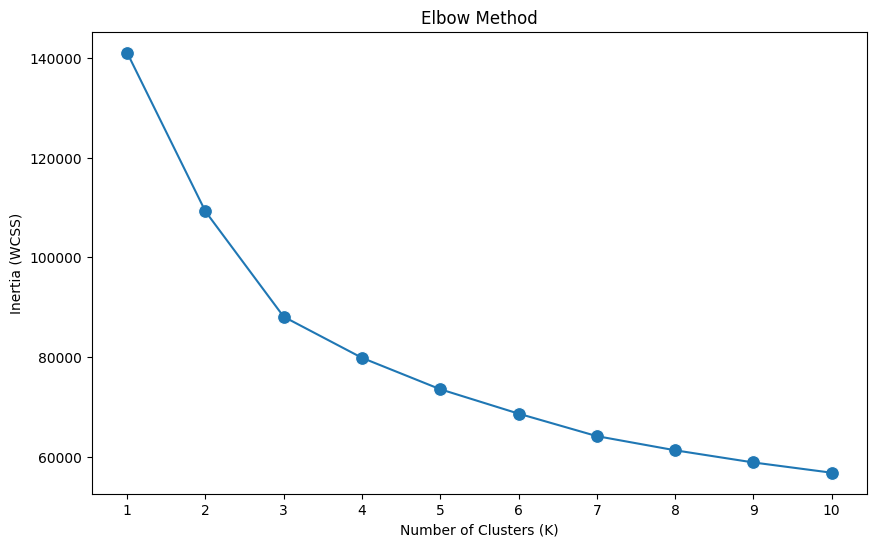

In [157]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, 11), y=inertia)
sns.scatterplot(x=range(1, 11), y=inertia, s=100)

plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")

plt.show()

From this we can say that their should be 3 or 4 clusters possible in this case

In [158]:
#Trying with 3 clusters
from sklearn.decomposition import PCA
# Apply PCA for dimensionality reduction (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [159]:
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PCA1", "PCA2"]
)

print(loadings.T)

                                   PCA1      PCA2
Age                           -0.080184  0.112899
Avg_BPM                        0.357695 -0.363686
Resting_BPM                   -0.213445 -0.414994
Session_Duration (hours)       0.273890  0.399610
Fat_Percentage                -0.221924 -0.395691
Workout_Frequency (days/week)  0.247642  0.440706
BMI                            0.047718 -0.010052
Base_MET                       0.435705 -0.289971
HR_Intensity                   0.437159 -0.296813
Calories_Burned (kcal)         0.501248  0.001474


From here we can see that PCA1 is dominated by features like calories burned, HR intensity, and MET, indicating overall workout and   PCA2 indicates a contrast between workout frequency/duration  resting BPM and fat percentage, representing fitness efficiency or adaptation

In [160]:
# Apply KMeans Clustering 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca)


In [161]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_pca, df['Cluster'])
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.388


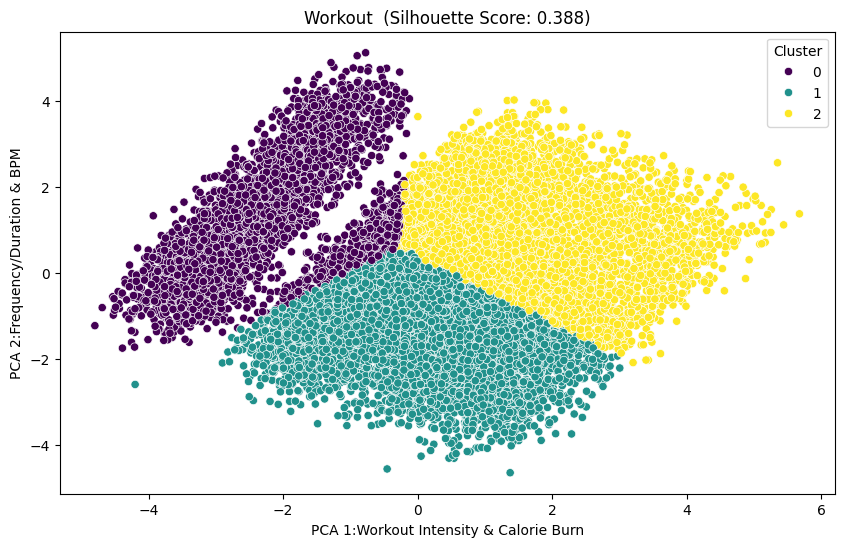

In [162]:
# 7. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='viridis')
plt.title(f'Workout  (Silhouette Score: {score:.3f})')
plt.xlabel('PCA 1:Workout Intensity & Calorie Burn')
plt.ylabel('PCA 2:Frequency/Duration & BPM')
plt.savefig('workout_clusters.png')

**🟣Cluster 0 Purple **Left side  Located on the left side (low PCA 1) Medium to high  PCA 2 means Lower intensity workouts But some moderate heart response
Likely low-intensity workouts (e.g., yoga, light activity)



**🟢 Cluster 1** (Green-Bottom side)
Located lower side (low PCA 2)
Medium PCA 1

 Meaning:Moderate calorie burn  Low heart rate response

📌 We can infer that their is Possibly of steady workouts (e.g., strength training, controlled exercise)


**🟡Cluster 2 **(Yellow – Right side) Located right side (high PCA 1) Medium to high PCA 2


**We can say that**

High intensity
High calorie burn + high BPM

**📌 Interpretation:**Likely high-intensity workouts (HIIT, cardio)



I used PCA to reduce dimensionality and plotted clusters using KMeans. By analyzing PCA loadings, I interpreted PC1 as workout intensity and PC2 as fitness efficiency. I then divided the plot into quadrants to segment users into meaningful behavioral groups

4CLUSTERS

In [163]:
# Apply KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca)

In [164]:
from sklearn.decomposition import PCA
# Applying  PCA for dimensionality reduction (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [165]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_pca, df['Cluster'])
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.372


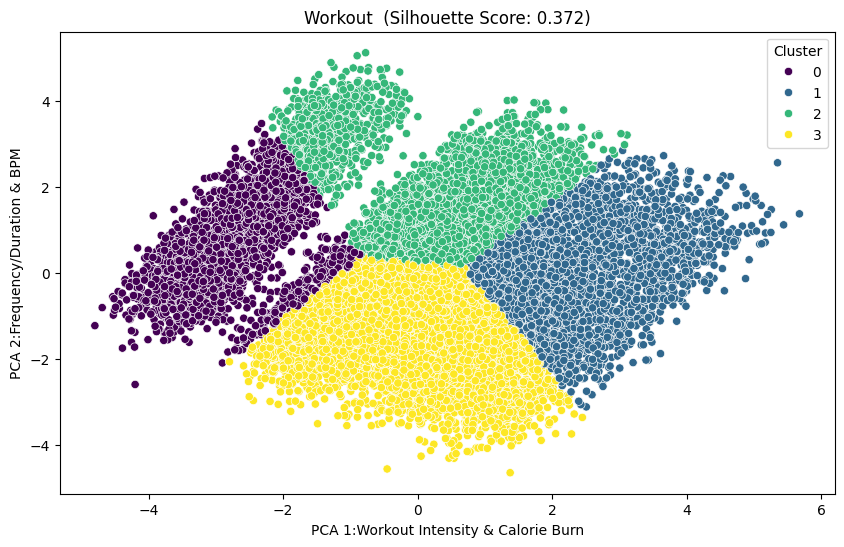

In [166]:
# 7. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='viridis')
plt.title(f'Workout  (Silhouette Score: {score:.3f})')
plt.xlabel('PCA 1:Workout Intensity & Calorie Burn')
plt.ylabel('PCA 2:Frequency/Duration & BPM')
plt.savefig('workout_clusters.png')

# **FINDINGS**
The clustering shows four main types of users based on workout behavior:

🟣 Cluster 0 (Purple) → Low-intensity users (beginners, casual exercisers,
 low calorie burn)

🔵 Cluster 1 (Blue) → High-intensity users (athletes, high calorie burn, performance-focused)

🟢 Cluster 2 (Green) → Consistent users (regular workouts, good duration & frequency, steady effort)

🟡 Cluster 3 (Yellow) → Irregular/fatigued users (low consistency, possible recovery issues)Density:The yellow cluster is very dense, suggesting a
large portion of the user base performs "standard" low-to-mid intensity,
shorter-duration workouts.

# **We chose 3 clusters as the optimal model because it yielded a higher Silhouette Score (0.388) compared to the 4-cluster model (0.372). This indicates that 3 groups provide the most distinct and stable segmentation of user behavior, avoiding the over segmentation of the intermediate user base."**

In [172]:
from sklearn.cluster import DBSCAN

# Applying  DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)

# Fit model and get cluster labels
df['Cluster'] = dbscan.fit_predict(X_pca)

# Print result
print("Clusters:", set(df['Cluster']))

Clusters: {0, -1}


From here we are getting only 2 clusters,

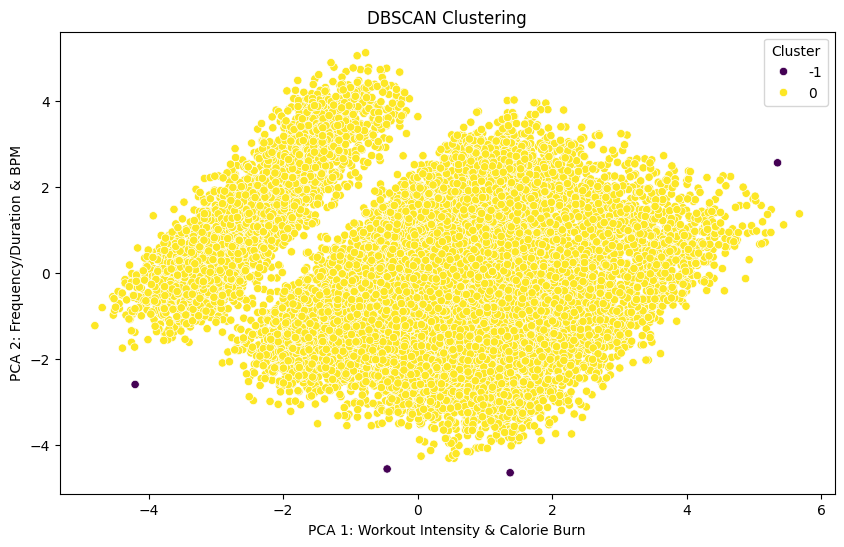

In [173]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title('DBSCAN Clustering')
plt.xlabel('PCA 1: Workout Intensity & Calorie Burn')
plt.ylabel('PCA 2: Frequency/Duration & BPM')

plt.show()

# DBSCAN  gives  one major cluster with a few outliers,
which indicates that the dataset does not have strong density-based separation and behaves more like a continuous distribution. This means users’ workout patterns change gradually rather than forming clearly dense groups. In this case,K-Means is more suitable because it separates data based on distance and givesclearer segments. However,DBSCAN is still useful for identifying outliers, which may represent unusual or extreme workout behavior